# eQTL preprocessing cont. + analysis

- Objective: to identify associations between structural variants (SVs) and gene expression (eQTL) in population data.

- SV: VCF from 1000 Genomes, 28 shared samples from Geuvadis.

- Expression: count matrix/TPM from Geuvadis RNA-seq (HDF5).

- Annotations: GENCODE v19 GTF.

- NOTE: we have abandoned full search all SVs - all genes in favor of cis-pair only testing (SVs near a gene, <= 1Mb). It significantly reduces computation time and is in line with eQTL analysis standards.

In [7]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
import random
import re

## Loading and preparing data

Loading expression from HDF5 (gene expressions):

In [8]:
# checking the column names 
with h5py.File('data/preprocessed/geuvadis_sv_expr.h5', 'r') as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

expr_genes
expression
samples
sv_gt
sv_ids


In [9]:
with h5py.File('data/preprocessed/geuvadis_sv_expr.h5', 'r') as h5:
    expr_matrix = h5['expression'][:]
    genes = [g.decode() if hasattr(g, 'decode') else g for g in h5['expr_genes'][:]]
    samples = [s.decode() if hasattr(s, 'decode') else s for s in h5['samples'][:]]

expr = pd.DataFrame(expr_matrix, index=samples, columns=genes).T
print(expr.shape)
print(expr.head())

(18870, 28)
                     HG00096    HG00097    HG00099    HG00100    HG00101  \
ENSG00000227232.4   4.323780   3.602970   3.631219   3.781200   4.297581   
ENSG00000237683.5   2.043834   1.812976   0.852204   1.226079   2.959925   
ENSG00000239906.1   1.083229   0.900620   0.339549   0.226199   1.592981   
ENSG00000225972.1  11.774630  11.614216  11.197738  11.684908  11.885773   
ENSG00000225630.1  11.894153  12.178942  11.397673  11.884973  12.131914   

                     HG00102    HG00103    HG00105    HG00106    HG00108  ...  \
ENSG00000227232.4   3.182880   4.154123   3.940888   4.343156   4.147351  ...   
ENSG00000237683.5   2.267890   1.849592   1.095066   1.874517   2.398478  ...   
ENSG00000239906.1   1.586163   1.015464   0.000000   0.641311   1.539910  ...   
ENSG00000225972.1  12.628022  12.027189  12.335571  11.572188  12.520845  ...   
ENSG00000225630.1  12.705209  11.994469  12.346259  11.774931  12.580176  ...   

                     HG00118    HG00119    H

## QC expression 

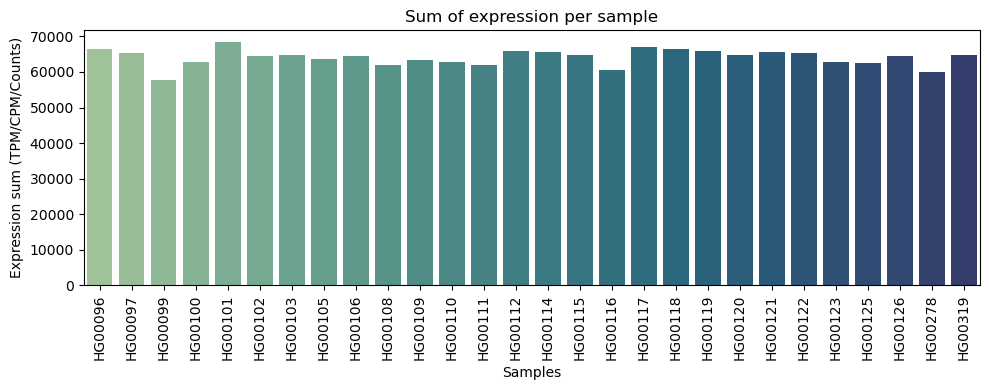

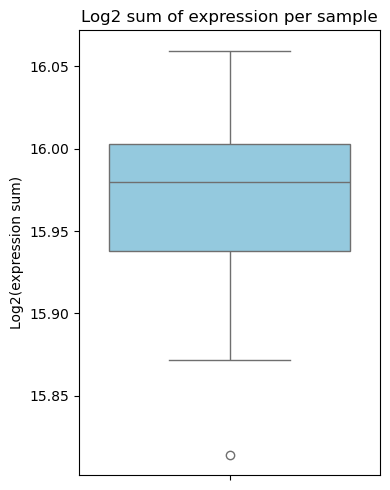

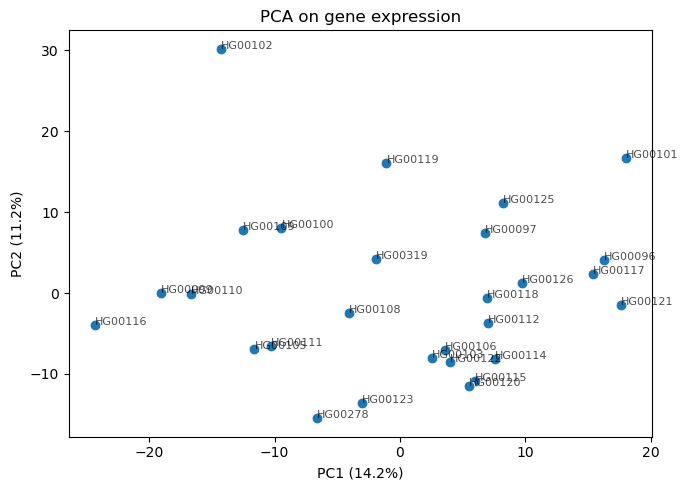

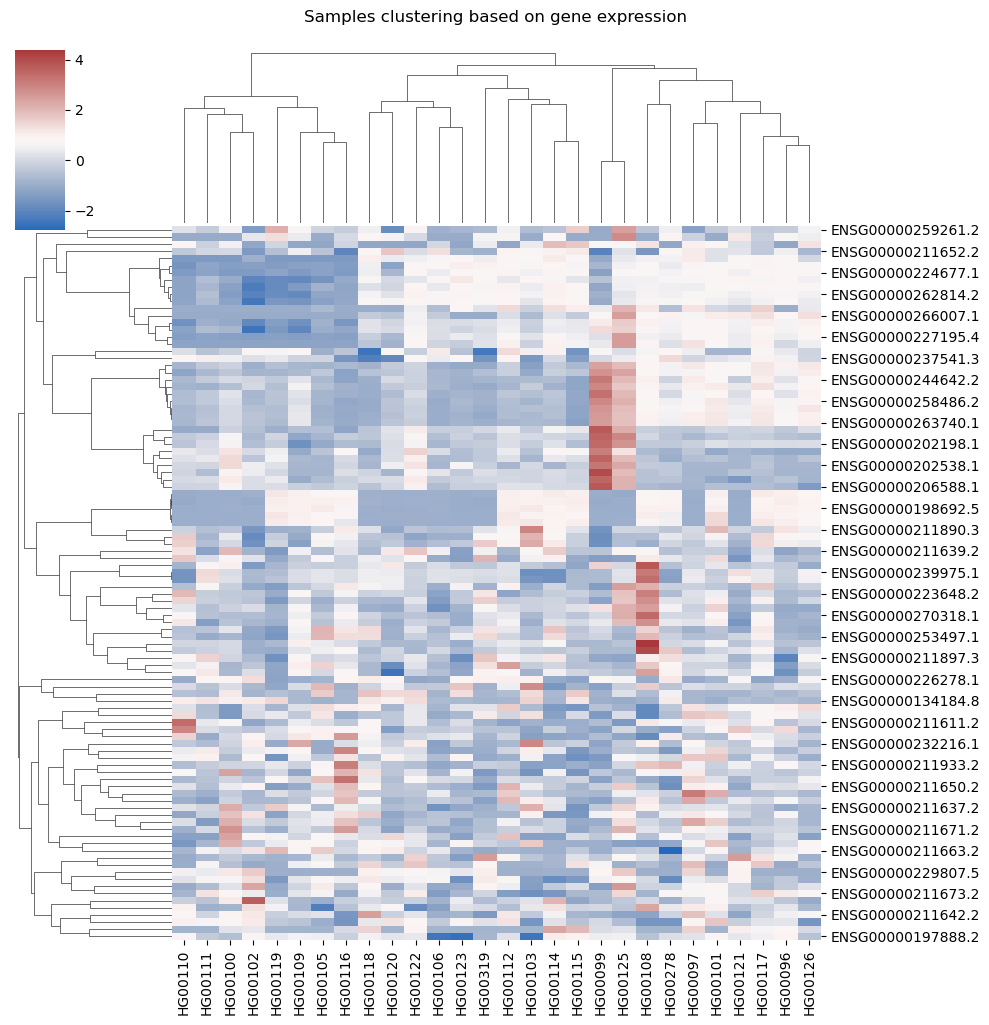

In [10]:
# sum of expressions per sample -- looking for outliers
sums = expr.sum(axis=0)
plt.figure(figsize=(10, 4))
sns.barplot(x=sums.index, y=sums.values, hue=sums.index, palette="crest", legend=False)
plt.xticks(rotation=90)
plt.xlabel("Samples")
plt.ylabel("Expression sum (TPM/CPM/Counts)")
plt.title("Sum of expression per sample")
plt.tight_layout()
plt.show()

# log2(sum) distribution
log_sums = np.log2(expr.sum(axis=0) + 1)
plt.figure(figsize=(4, 5))
sns.boxplot(y=log_sums, color="skyblue")
plt.ylabel("Log2(expression sum)")
plt.title("Log2 sum of expression per sample")
plt.tight_layout()
plt.show()

# PCA on expression data
expr_log = np.log2(expr + 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(expr_log.T)  

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], s=60)
for i, sample in enumerate(expr.columns):
    plt.text(X_pca[i,0], X_pca[i,1], sample, fontsize=8, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA on gene expression')
plt.tight_layout()
plt.show()

# clustermap (top 500 genes)
top_genes = expr.var(axis=1).sort_values(ascending=False).index[:100]
sns.clustermap(expr.loc[top_genes], metric="correlation", z_score=0, cmap='vlag')
plt.suptitle('Samples clustering based on gene expression', y=1.02)
plt.show()


Loading SV genotypes:

In [11]:
geno = pd.read_csv('data/1kg_sv/genotypes_numeric.txt', sep='\t', index_col=0)
print(geno.shape)
print(geno.iloc[10:, :5])

(12321, 445)
                              HG00096  HG00097  HG00099  HG00100  HG00101
ID                                                                       
BI_GS_DEL1_B5_P0002_270           0.0      0.0      0.0      0.0      0.0
YL_CN_YRI_28                      0.0      0.0      0.0      0.0      0.0
DUP_gs_CNV_1_1627805_1673809      0.0      0.0      0.0      0.0      0.0
BI_GS_DEL1_B5_P0002_358           0.0      0.0      0.0      0.0      0.0
UW_VH_14735                       0.0      0.0      0.0      0.0      0.0
...                               ...      ...      ...      ...      ...
YL_CN_IBS_4183                    NaN      2.0      2.0      1.0      NaN
DEL_pindel_54962                  NaN      1.0      1.0      1.0      NaN
UW_VH_1324                        NaN      0.0      0.0      1.0      NaN
L1_umary_LINE1_3150               0.0      0.0      0.0      1.0      0.0
UW_VH_7995                        NaN      0.0      0.0      0.0      NaN

[12311 rows x 5 columns]

Checking shared ("synchronized") samples:

In [12]:
shared_samples = sorted(list(set(expr.columns) & set(geno.columns)))
expr_sync = expr[shared_samples]
geno_sync = geno[shared_samples]

print(f"Number of common samples: {len(shared_samples)}")
print("Common samples:", shared_samples[:28])
print("The shape of expression matrix:", expr_sync.shape)
print("The shape of the genotype matrix:", geno_sync.shape)

# checking if the order of samples is the same
assert all(expr_sync.columns == geno_sync.columns), "The order of samples is not correct."

Number of common samples: 28
Common samples: ['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101', 'HG00102', 'HG00103', 'HG00105', 'HG00106', 'HG00108', 'HG00109', 'HG00110', 'HG00111', 'HG00112', 'HG00114', 'HG00115', 'HG00116', 'HG00117', 'HG00118', 'HG00119', 'HG00120', 'HG00121', 'HG00122', 'HG00123', 'HG00125', 'HG00126', 'HG00278', 'HG00319']
The shape of expression matrix: (18870, 28)
The shape of the genotype matrix: (12321, 28)



We only perform further analysis on those samples that appear in both the expression and the SV genotype matrix as this ensures that each column corresponds to the same individual in both matrices:

 SV-gene single association test (checking if a sample has correct results):

In [13]:
sv_id = geno_sync.index[0]     # first SV
gene_id = expr_sync.index[0]   # first gene

X = geno_sync.loc[sv_id].astype(float)
y = expr_sync.loc[gene_id].astype(float)

print(X.shape, y.shape)

# linear regression
X_design = sm.add_constant(X)
model = sm.OLS(y, X_design)
results = model.fit()
print(results.summary())

(28,) (28,)
                            OLS Regression Results                            
Dep. Variable:      ENSG00000227232.4   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.744
Date:                Wed, 04 Jun 2025   Prob (F-statistic):              0.198
Time:                        11:55:32   Log-Likelihood:                -10.855
No. Observations:                  28   AIC:                             25.71
Df Residuals:                      26   BIC:                             28.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1672    

SV–gen regression test (small subset per sample):

In [15]:
from tqdm import tqdm

N_SV = 1000
N_GENES = 1000
sv_subset = geno_sync.index[:N_SV]
gene_subset = expr_sync.index[:N_GENES]

results_list = []
for sv_id in tqdm(sv_subset):
    X = geno_sync.loc[sv_id].astype(float)
    for gene_id in gene_subset:
        y = expr_sync.loc[gene_id].astype(float)
        mask = (~X.isna()) & (~y.isna())
        if mask.sum() < 10: continue
        X_design = sm.add_constant(X[mask])
        y_sub = y[mask]
        fit = sm.OLS(y_sub, X_design).fit()
        if len(fit.pvalues) < 2: continue
        results_list.append({
            'sv': sv_id,
            'gene': gene_id,
            'pvalue': fit.pvalues.iloc[1],
            'beta': fit.params.iloc[1],
            'n': mask.sum()
        })

df_results = pd.DataFrame(results_list)
df_results['FDR'] = multipletests(df_results['pvalue'], method='fdr_bh')[1]
print("Number of tested SV-gene pairs:", len(df_results))


100%|██████████| 1000/1000 [21:21<00:00,  1.28s/it]


Number of tested SV-gene pairs: 999000


"Top hits" visualization:

In [16]:
for cutoff in [0.01, 0.05, 0.1, 0.2]:
    print(f"Association number with p-value < {cutoff}: {(df_results['pvalue'] < cutoff).sum()}")
    print(f"Association number with FDR < {cutoff}: {(df_results['FDR'] < cutoff).sum()}")

df_results.sort_values('FDR').head(50).to_csv('data/top_hits.txt', sep='\t', index=False)

Association number with p-value < 0.01: 7839
Association number with FDR < 0.01: 0
Association number with p-value < 0.05: 35129
Association number with FDR < 0.05: 0
Association number with p-value < 0.1: 68718
Association number with FDR < 0.1: 0
Association number with p-value < 0.2: 136330
Association number with FDR < 0.2: 0


We can observe that 

## Preparation of SV/gene positions and cis-pair determination

In [20]:
# SV positions (VCF)
vcf_sv = pd.read_csv('data/1kg_sv/sv_geuvadis_only.vcf.gz', sep='\t', comment='#', header=None,
    usecols=[0,1,2,7], names=['CHROM', 'POS', 'ID', 'INFO'],
    dtype={'CHROM': str, 'POS': int, 'ID': str, 'INFO': str}
)
def get_end(info):
    m = re.search(r'END=(\d+)', info)
    return int(m.group(1)) if m else None
vcf_sv['END'] = vcf_sv['INFO'].apply(get_end)
vcf_sv['END'] = vcf_sv['END'].fillna(vcf_sv['POS'])
vcf_sv['POS'] = vcf_sv['POS'].astype(int)
sv_positions = vcf_sv.set_index('ID')[['CHROM','POS','END']].T.to_dict()

# GTF genes
gtf = pd.read_csv('data/reference/gencode.v19.annotation.gtf', sep='\t', comment='#', header=None,
    names=['chr', 'src', 'feature', 'start', 'end', 'dot', 'strand', 'dot2', 'info'])
gtf_genes = gtf[gtf['feature'] == 'gene']
def get_gene_id(info): m = re.search(r'gene_id "([^"]+)"', info); return m.group(1).split('.')[0] if m else None
gtf_genes['gene_id'] = gtf_genes['info'].apply(get_gene_id)
gene_positions = gtf_genes.set_index('gene_id')[['chr', 'start', 'end']].to_dict(orient='index')


# we ensure chromosome names are prefixed with 'chr'
for sv in sv_positions:
    chrom = sv_positions[sv]['CHROM']
    if not str(chrom).startswith('chr'):
        sv_positions[sv]['CHROM'] = 'chr'+str(chrom)
for gene in gene_positions:
    if not str(gene_positions[gene]['chr']).startswith('chr'):
        gene_positions[gene]['chr'] = 'chr'+str(gene_positions[gene]['chr'])

/tmp/ipykernel_50349/1008612902.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtf_genes['gene_id'] = gtf_genes['info'].apply(get_gene_id)


Cis-par determination (1 Mb):

In [21]:
window = 1_000_000  # 1 Mb
cis_pairs = []
for sv_id, sv_pos in sv_positions.items():
    for gene_id, gene_pos in gene_positions.items():
        if sv_pos['CHROM'] == gene_pos['chr']:
            dist = min(abs(sv_pos['POS'] - gene_pos['start']), abs(sv_pos['END'] - gene_pos['end']))
            if dist <= window:
                cis_pairs.append((sv_id, gene_id))
print(f'Number of cis pairs: {len(cis_pairs)}')


Number of cis pairs: 550457


## SV–gene association tests (cis-pairs)

In [22]:
from tqdm import tqdm

MAX_TESTS = 550457
subset_cis_pairs = cis_pairs[:MAX_TESTS]

results_list = []
for sv_id, gene_id in tqdm(subset_cis_pairs):
    if sv_id not in geno_sync.index:
        continue
    expr_gene_id = [g for g in expr_sync.index if g.split('.')[0] == gene_id]
    if not expr_gene_id:
        continue
    expr_gene_id = expr_gene_id[0]
    X = geno_sync.loc[sv_id].astype(float)
    y = expr_sync.loc[expr_gene_id].astype(float)
    mask = (~X.isna()) & (~y.isna())
    if mask.sum() < 10: continue
    X_design = sm.add_constant(X[mask])
    y_sub = y[mask]
    fit = sm.OLS(y_sub, X_design).fit()
    if len(fit.pvalues) < 2: continue
    results_list.append({
        'sv': sv_id,
        'gene': expr_gene_id,
        'pvalue': fit.pvalues.iloc[1],
        'beta': fit.params.iloc[1],
        'n': mask.sum()
    })

df_results = pd.DataFrame(results_list)
df_results['FDR'] = multipletests(df_results['pvalue'], method='fdr_bh')[1]
print(df_results.head())


100%|██████████| 550457/550457 [21:30<00:00, 426.61it/s]  


                sv               gene    pvalue      beta   n  FDR
0  ALU_umary_ALU_2  ENSG00000227232.4  0.198201 -0.497545  28  NaN
1  ALU_umary_ALU_2  ENSG00000237683.5  0.524351  0.355794  28  NaN
2  ALU_umary_ALU_2  ENSG00000239906.1  0.616328  0.269783  28  NaN
3  ALU_umary_ALU_2  ENSG00000225972.1  0.916232 -0.056195  28  NaN
4  ALU_umary_ALU_2  ENSG00000225630.1  0.702636  0.191698  28  NaN


## Statistics and plots

Number of tested SV-gene pairs: 178956
Number of associations with p-value < 0.01: 1648
Number of associations with FDR < 0.01: 0
Number of associations with p-value < 0.05: 6512
Number of associations with FDR < 0.05: 0
Number of associations with p-value < 0.1: 12443
Number of associations with FDR < 0.1: 0
Number of associations with p-value < 0.2: 24645
Number of associations with FDR < 0.2: 0


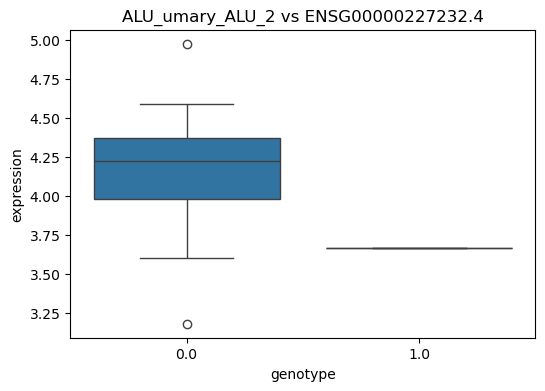

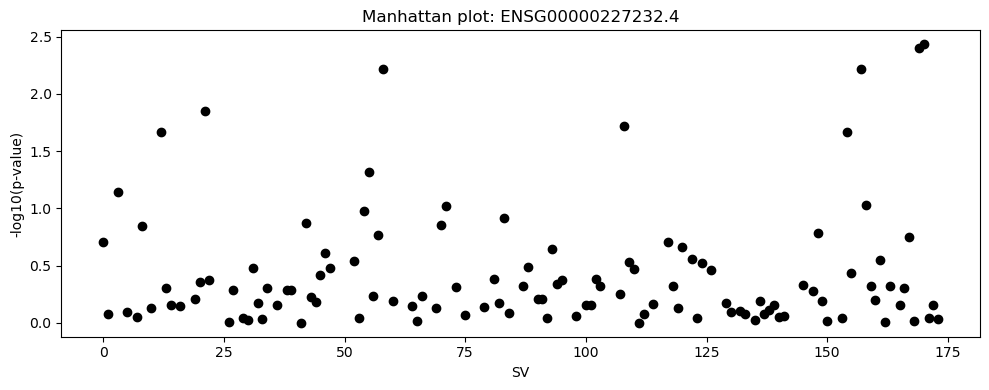

In [23]:
print("Number of tested SV-gene pairs:", len(df_results))
for thresh in [0.01, 0.05, 0.1, 0.2]:
    print(f"Number of associations with p-value < {thresh}: {(df_results['pvalue'] < thresh).sum()}")
    print(f"Number of associations with FDR < {thresh}: {(df_results['FDR'] < thresh).sum()}")

# Boxplot dla top hitu
if not df_results.empty:
    top = df_results.sort_values('FDR').iloc[0]
    sv = top['sv']
    gene = top['gene']
    df_plot = pd.DataFrame({'genotype': geno_sync.loc[sv], 'expression': expr_sync.loc[gene]})
    plt.figure(figsize=(6,4))
    sns.boxplot(x='genotype', y='expression', data=df_plot)
    plt.title(f'{sv} vs {gene}')
    plt.show()
    
    # Manhattan plot dla top genu
    selected_gene = top['gene']
    df_gene = df_results[df_results['gene'] == selected_gene]
    plt.figure(figsize=(10, 4))
    plt.scatter(range(len(df_gene)), -np.log10(df_gene['pvalue']), c='black')
    plt.xlabel('SV')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Manhattan plot: {selected_gene}')
    plt.tight_layout()
    plt.show()


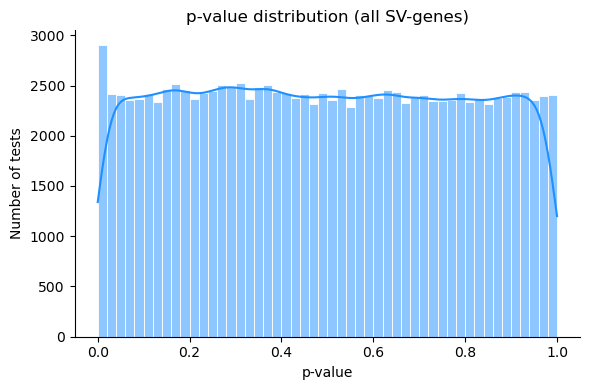

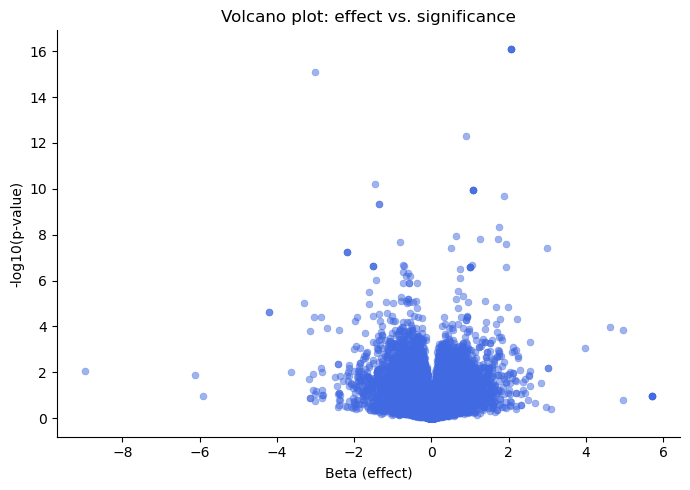

/tmp/ipykernel_50349/81495726.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


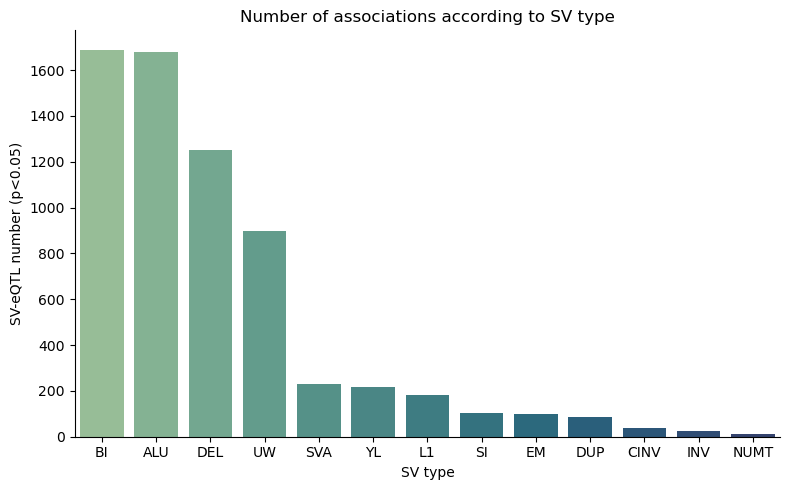

In [24]:

# Histogram of p-value distribution
plt.figure(figsize=(6,4))
sns.histplot(df_results['pvalue'], bins=50, color="dodgerblue", edgecolor="white", kde=True)
plt.xlabel('p-value')
plt.ylabel('Number of tests')
plt.title('p-value distribution (all SV-genes)')
sns.despine()
plt.tight_layout()
plt.show()


# Volcano plot
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df_results['beta'],
    y=-np.log10(df_results['pvalue']),
    alpha=0.5,
    s=25,
    color="royalblue",
    edgecolor=None
)
plt.xlabel('Beta (effect)')
plt.ylabel('-log10(p-value)')
plt.title('Volcano plot: effect vs. significance')
sns.despine()
plt.tight_layout()
plt.show()



# Barplot of SV-eQTL number according to SV 
df_results['sv_type'] = df_results['sv'].str.split('_').str[0]
sv_type_counts = df_results[df_results['pvalue'] < 0.05]['sv_type'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=sv_type_counts.index,
    y=sv_type_counts.values,
    palette="crest"
)
plt.xlabel('SV type')
plt.ylabel('SV-eQTL number (p<0.05)')
plt.title('Number of associations according to SV type')
sns.despine()
plt.tight_layout()
plt.show()



## Results exports

In [25]:
df_results.sort_values('FDR').head(50).to_csv('data/top_hits.txt', sep='\t', index=False)